This notebook is a demo for ArchVelo. 

ArchVelo is a method for modeling gene regulation and inferring cell trajectories using scRNA+ATAC-seq. Here we apply ArchVelo to a E18 stage scRNA+ATAC mouse embryonic brain dataset. We apply ArchVelo, demonstrate its fits for several key markers and showcase archetypal velocity decomposition on the same UMAP.

Preprocessed matrices for this analysis should be downloaded into the processed_data/ folder from  https://doi.org/10.6084/m9.figshare.30096616.v2

The inputs here are as follows:
1) adata_rna.h5ad - scRNA count matrix, preprocessed for ArchVelo analysis.
2) atac_AA.h5ad - scATAC count matrix, denoised via archetypal analysis and required to run ArchVelo
3) arches.h5ad - chromatin accessibility archetypes, obtained via archetypal analysis (AA) on the scATAC modality
4) gene_weights.csv - gene-specific loadings from AA on the scATAC modality

The original dataset is available through 10X (https://www.10xgenomics.com/datasets/fresh-embryonic-e-18-mouse-brain-5-k-1-standard-1-0-0) and the full analysis is available at https://github.com/pritykinlab/ArchVelo_notebooks


In [1]:
import ArchVelo as av

In [2]:
import pandas as pd
import scanpy as sc

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

In [5]:
num_comps = 10
n_jobs = 100

In [6]:
n_neigh = 50
n_pcs=30

In [7]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'
os.makedirs(model_outdir, exist_ok = True)

# Read in data

In [8]:
# Load processed RNA
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')
# Denoised ATAC
atac_AA = sc.read_h5ad(data_outdir+'adata_atac_AA_denoised.h5ad')
# Archetypes
smooth_arch = sc.read_h5ad(data_outdir+'arches.h5ad')
# Archetypal weights per gene
gene_weights = pd.read_csv(data_outdir+'gene_weights.csv', index_col = [0])
    

These intermediate inputs are obtained from adata_atac_raw and peak_annotation as below. See https://github.com/pritykinlab/ArchVelo_notebooks for detailed analysis.


In [9]:
# adata_atac_raw = sc.read_h5ad(data_outdir+'adata_atac_raw.h5ad')
# peak_annotation = pd.read_csv(PATH_TO_PEAK_ANNOT, index_col = [0])
# XC_raw, S_raw = av.apply_AA_no_test(adata_atac_raw, k = num_comps,
#                   outdir = model_outdir+'archetypes/')
# _, gene_weights = av.annotate_and_summarize(S_raw, peak_annotation, 
#                                             outdir = model_outdir)
# gene_weights = gene_weights.loc[:, adata_rna.var_names]
# atac_AA = av.create_denoised_atac(adata_rna, gene_weights, 
#                                   XC_raw, model_outdir = model_outdir,
#                                   n_pcs=n_pcs, n_neighbors=n_neigh)
# smooth_arches = sc.read_h5ad(model_outdir+"arches.h5ad")

# Apply ArchVelo

We apply ArchVelo to the dataset and visualize the results.

In [10]:
# Main method, this can take around 15 minutes
avel = av.apply_ArchVelo_full(adata_rna,
                    atac_AA,
                    smooth_arch,
                    gene_weights,
                    model_outdir,
                    n_jobs = n_jobs,
                    n_neighbors = n_neigh,
                    n_pcs = n_pcs)

Missing connectivities in ATAC adata object, using RNA connectivities instead


  0%|          | 0/930 [00:00<?, ?it/s]

Calculating velocity layers for 903 genes...
Assembling AnnData...


computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'ArchVelo result'}>

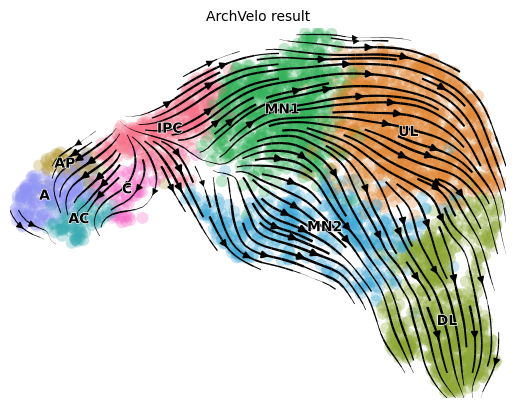

In [11]:
# Visualize
av.velocity_graph(avel)
av.latent_time(avel)
av.velocity_embedding_stream(avel, 
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = 'ArchVelo result')

In [12]:
# Write
avel.write(model_outdir+'archvelo_result.h5ad')

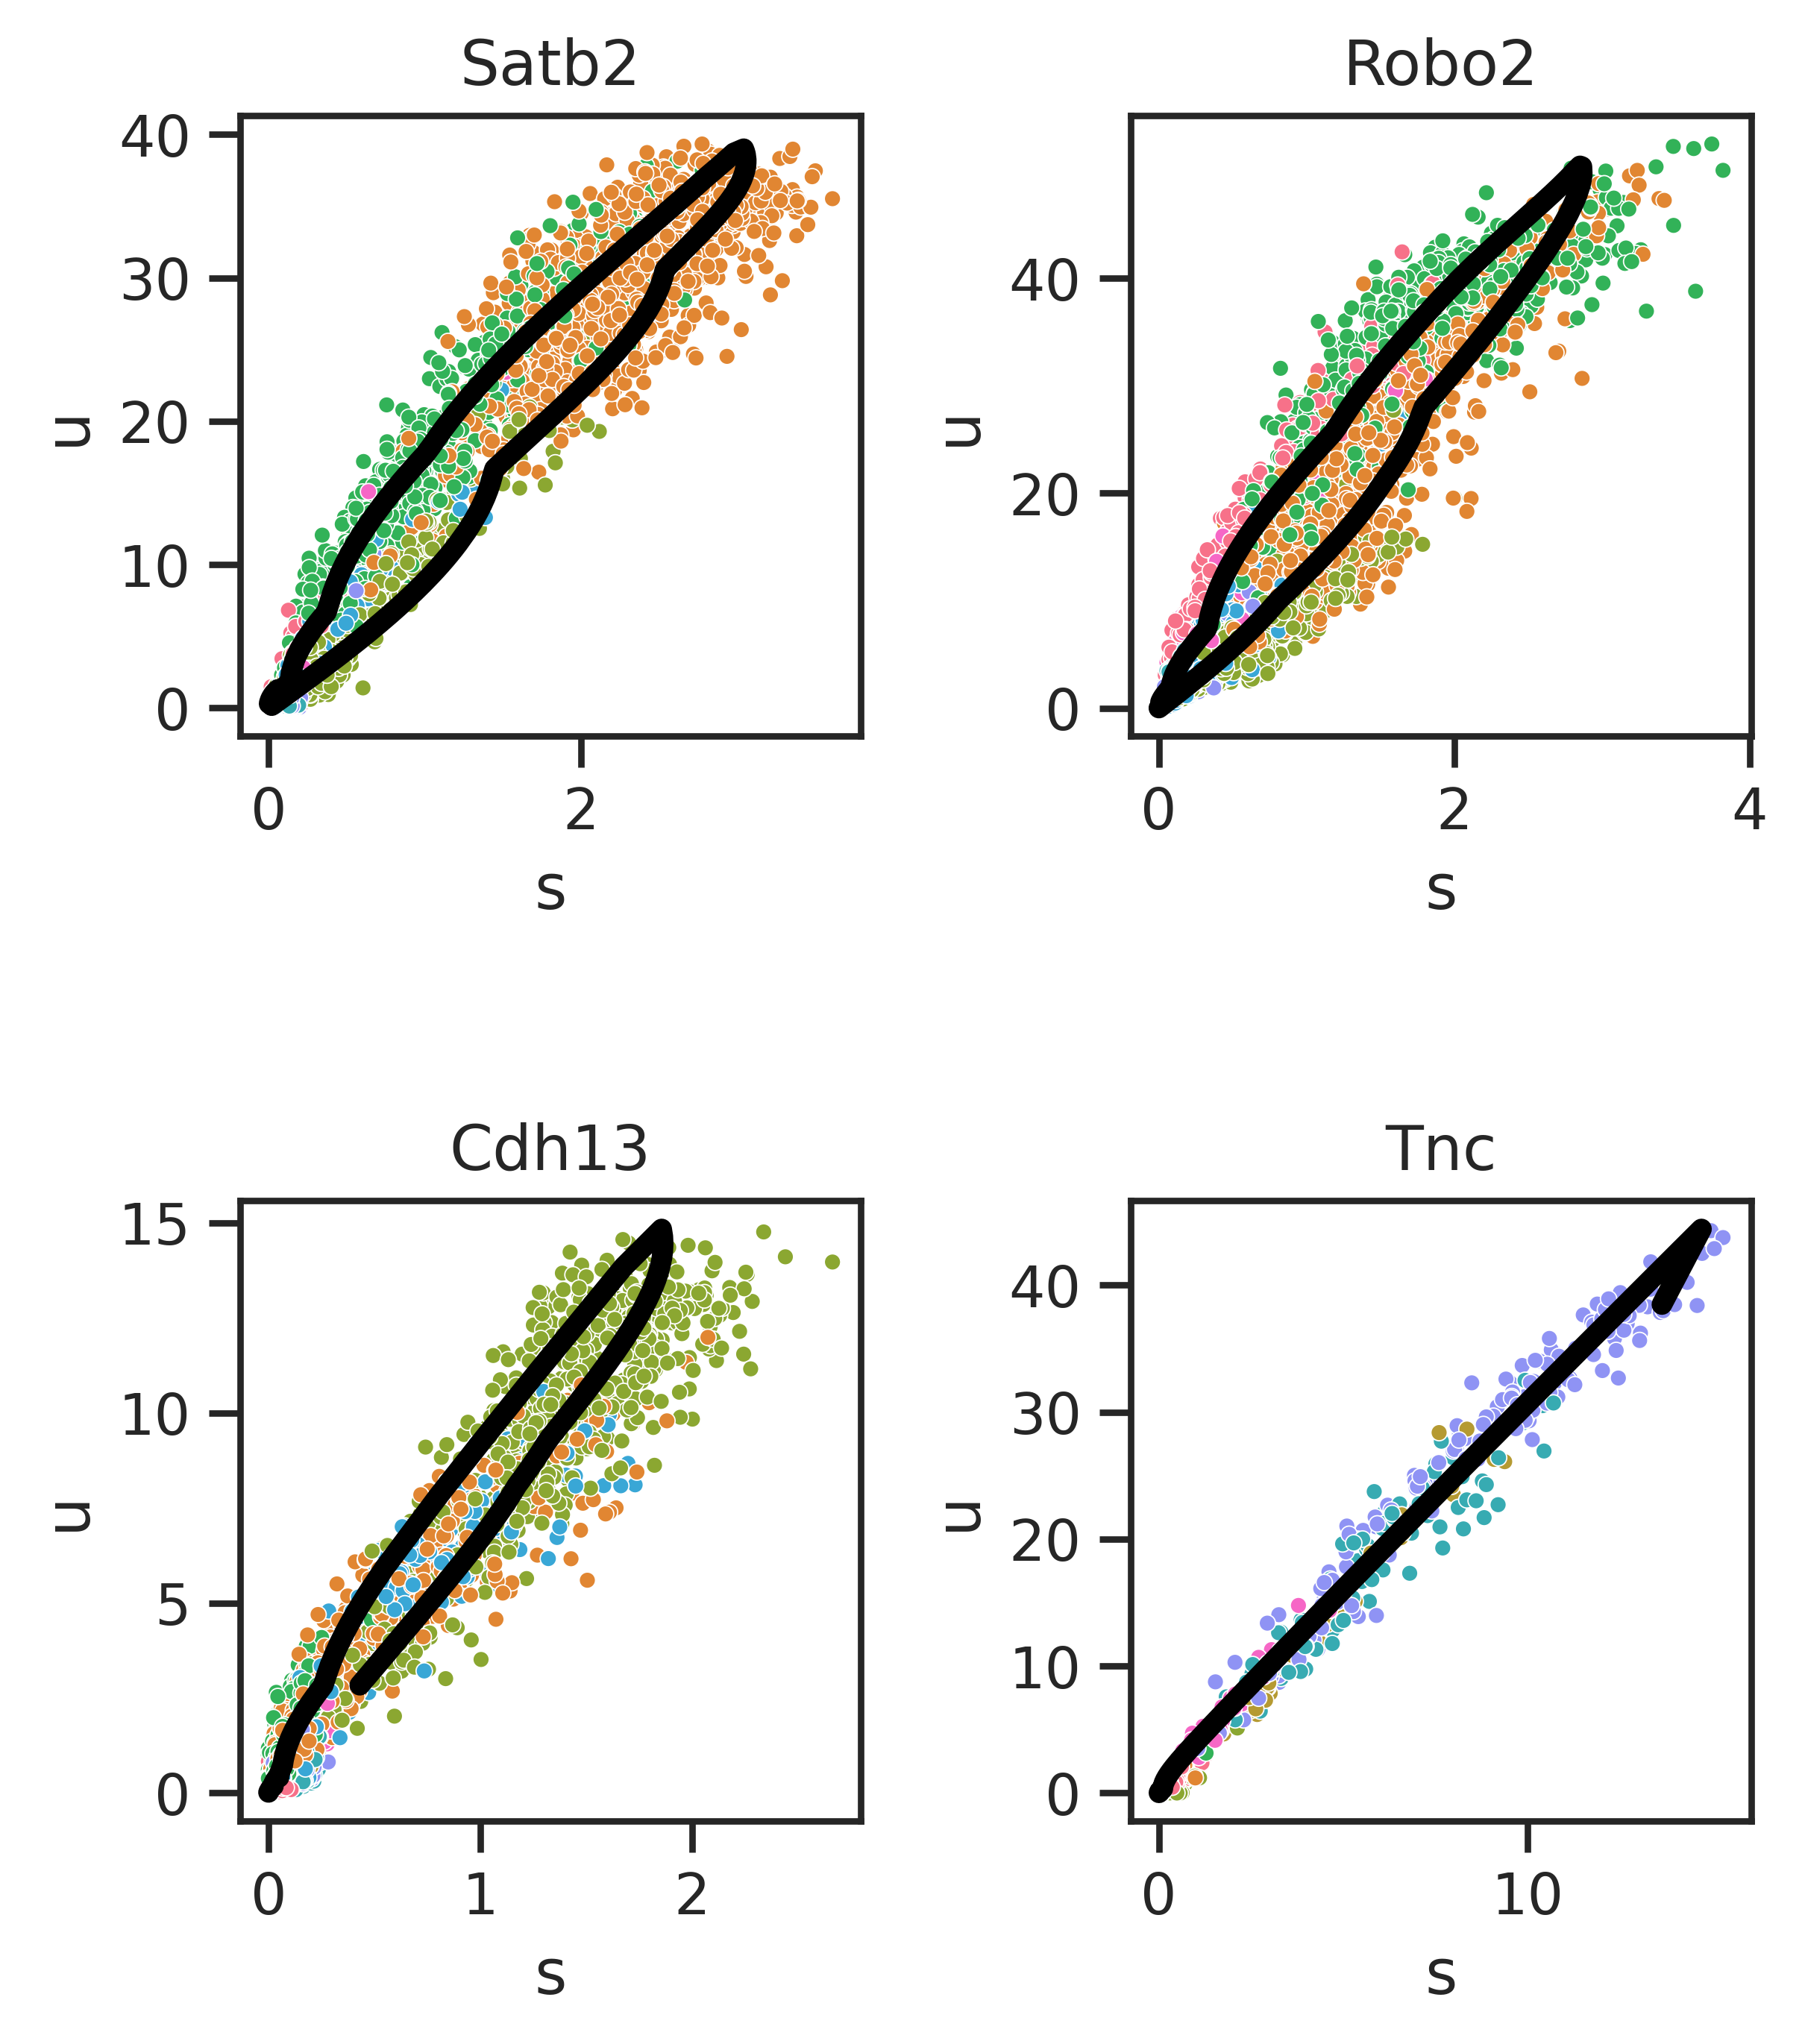

In [13]:
# Some examples
sns.set(style = 'ticks', font_scale = 1)
# make palette
pal = dict(zip(avel.obs['cell_type_abbr'].cat.categories,avel.uns['cell_type_abbr_colors']))
genes = ['Satb2',  
         'Robo2',
         'Cdh13', 
         'Tnc']
fig, axes = plt.subplots(2,2,figsize = (5,6), 
                         dpi = 500)

i = 0
for g in genes:
    ax = axes[i //2, i %2]
    i+=1
    ax.set_box_aspect(1)
    av.plot_phase(avel, 
               g, 
               ax = ax,
               color_by = 'cell_type_abbr',
               pal = pal,
               s = 10,
                    )
    ax.set_title(g)
    ax.set_ylabel('u')
    ax.set_xlabel('s')
plt.tight_layout()

# Trajectory components

Now archetypal velocity field decomposition is possible. Each component corresponds to one archetype and can be analyzed further.

In [14]:
# Read
avel = sc.read_h5ad(model_outdir+'archvelo_result.h5ad')

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:08) --> added 
    'velo_s_comp_5_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_comp_5_norm_umap', embedded velocity vectors (adata.obsm)
computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velo_s_comp_8_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_comp_8_norm_umap', embedded velocity vectors (adata.obsm)


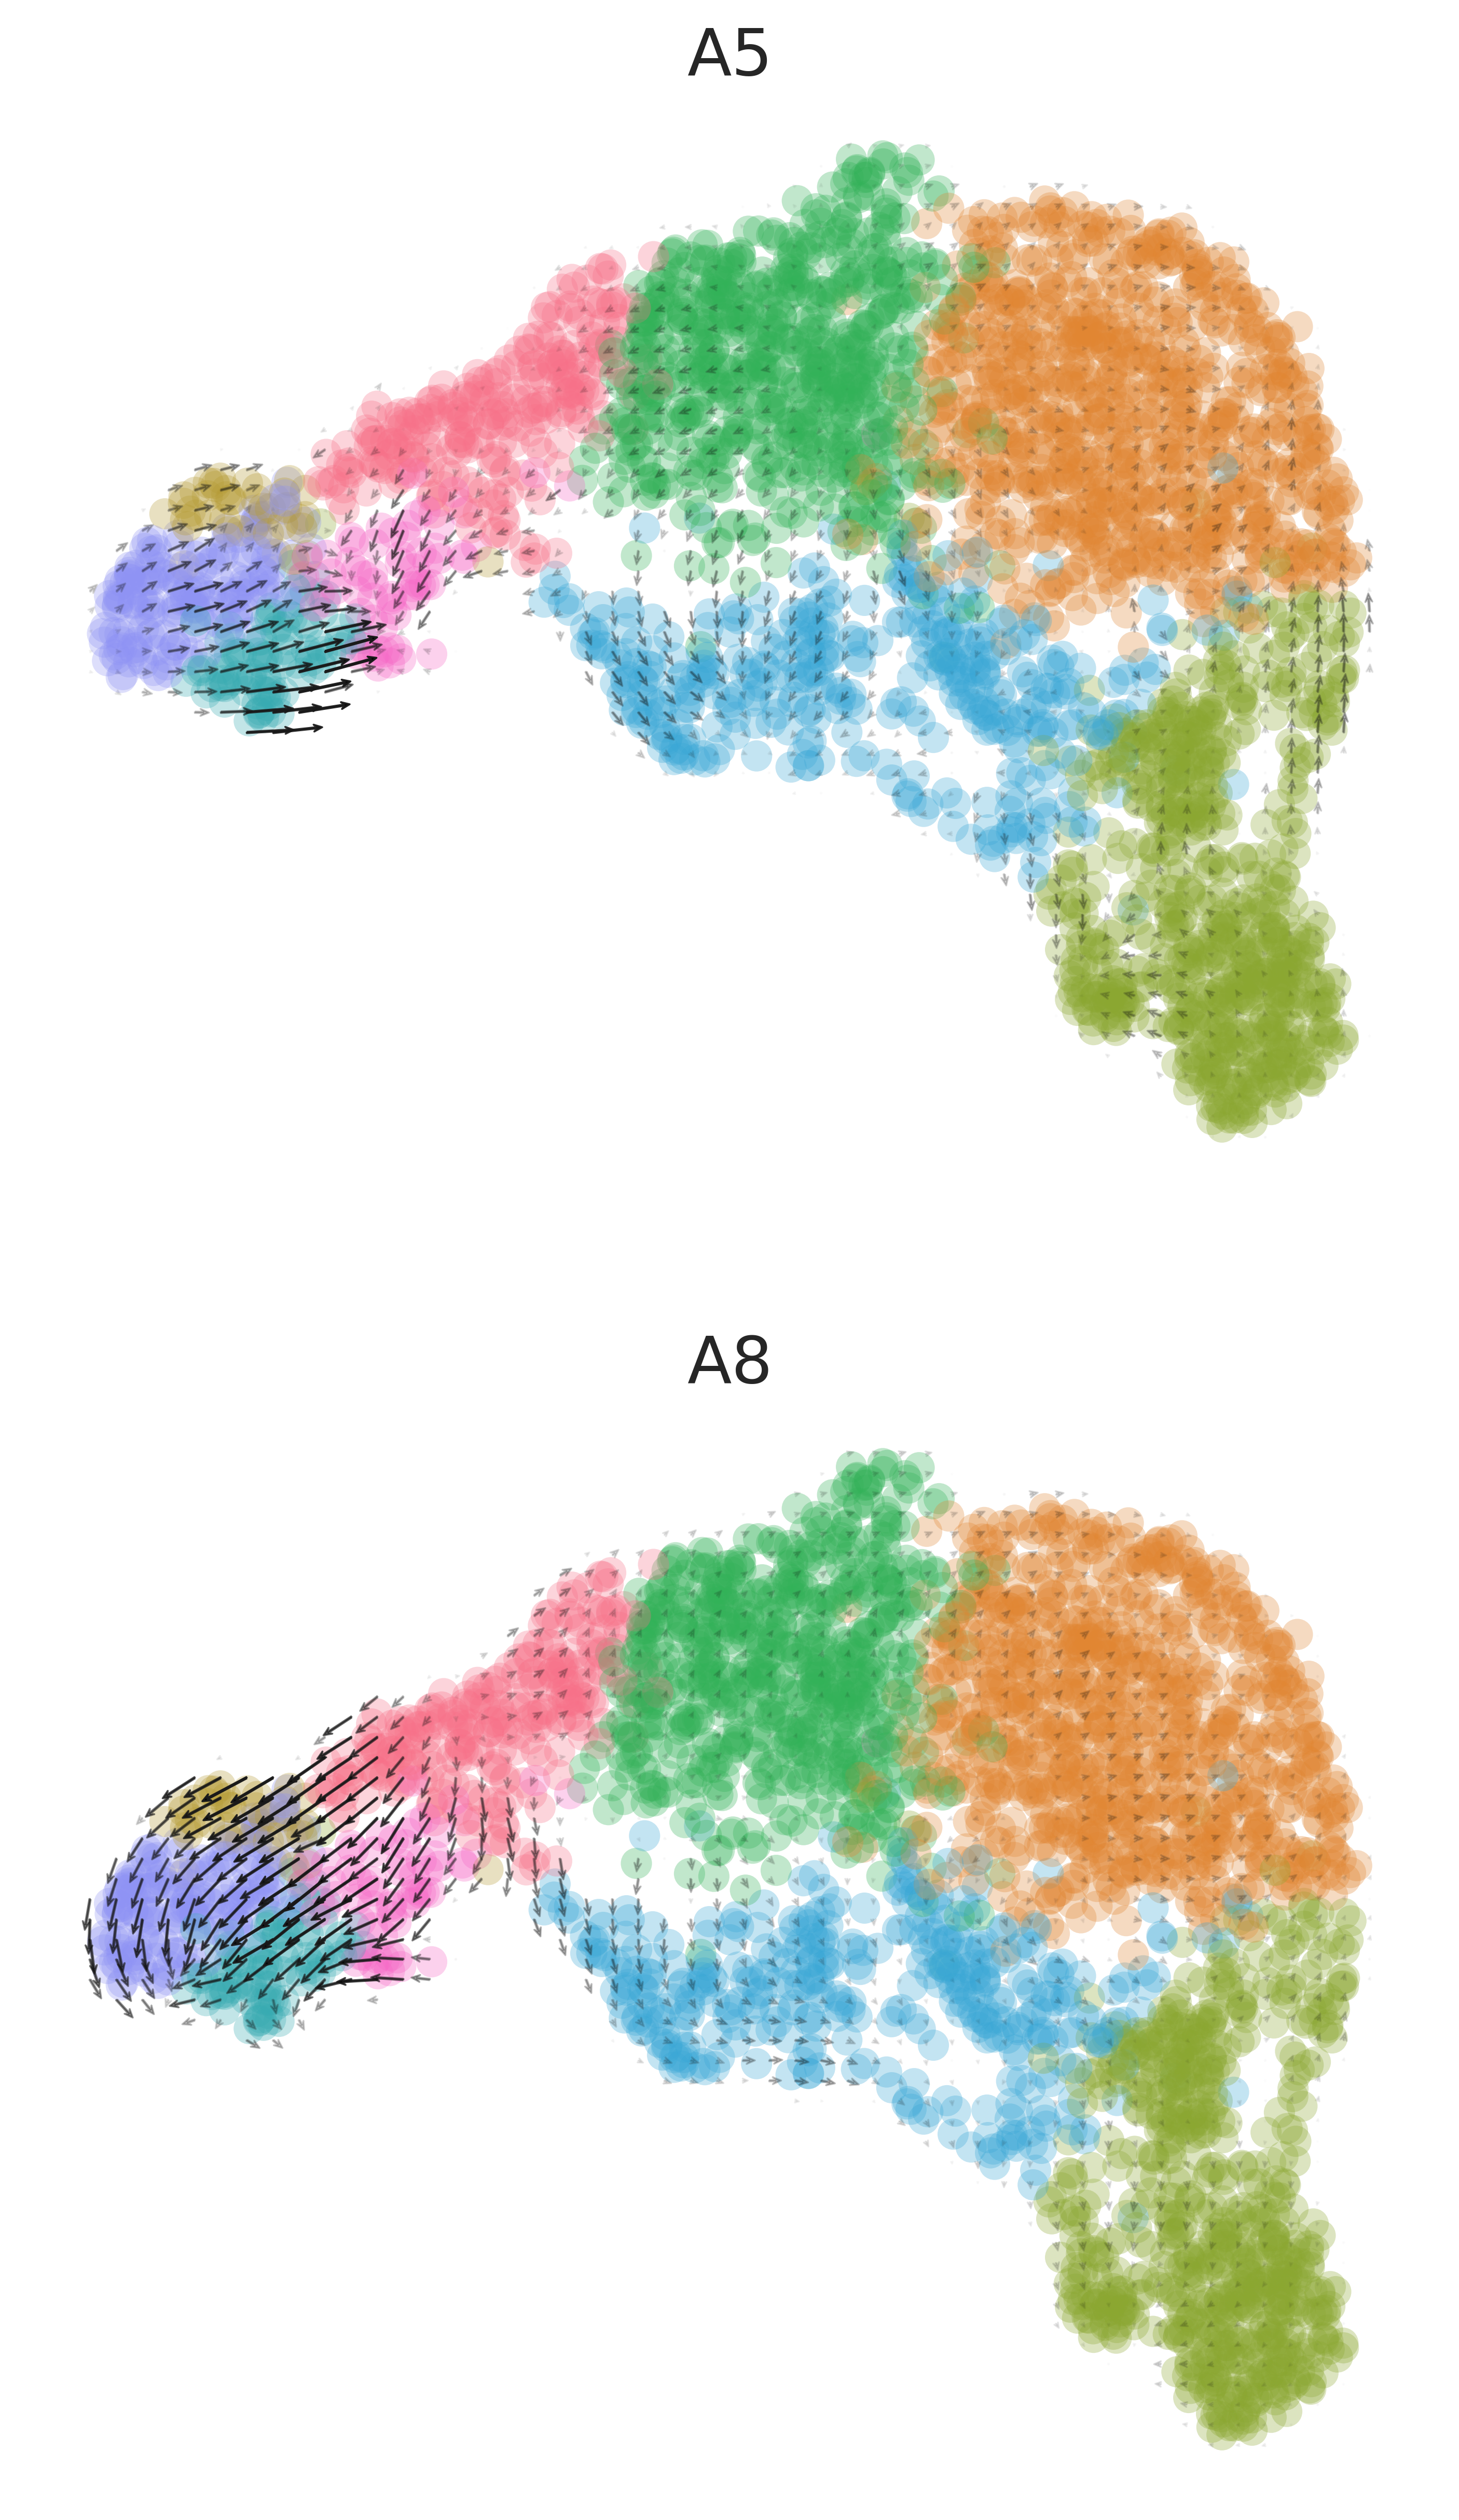

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [17]:
# Visualize two components
fig, axes = plt.subplots(2,1, dpi = 500, figsize = (7,12))
j = 0
for i in [5,8]:
    comp = i
    ax = axes[j]
    j+=1
    key_vel = 'velo_s_comp_'+str(comp)
    av.vis_velo_on_grid(avel,
                 key_vel = key_vel,
                 color_by = 'cell_type_abbr',
                 title = 'A'+str(i),
                 recalculate_graph = True,
                 ax = ax)